In [92]:
import coast
import numpy as np
import scipy.io
import matplotlib.pylab as plt

In [93]:
fn_domain="/gws/nopw/j04/class_vol2/senemo/RUNS2024r01/GS1p0_notide/config/domain_cfg.nc"
LME_gridinfo=np.load('../Data/LME_gridinfo_V4.npz')
a=scipy.io.loadmat('../Data/ORCA025_ROAM_GLB_LMEmaskV4.mat')
LME_mask=a['LME_mask'][:,:].T
J_offset=186 #account for extra rows in eORCA if data is made for normal ORCA
fn_config_t_grid = '../Config/senemo_grid_t.json'

In [94]:

for ilme in [11]:#range(63):    
    LME_name = LME_gridinfo['DOMNAM'][ilme]
    imin = LME_gridinfo['i_min'][ilme]-1
    imax = LME_gridinfo['i_max'][ilme]+1
    jmin = LME_gridinfo['j_min'][ilme] + J_offset-1
    jmax = LME_gridinfo['j_max'][ilme] + J_offset+1
    jmin0 = LME_gridinfo['j_min'][ilme]-1
    jmax0 = LME_gridinfo['j_max'][ilme]+1
    
    lims=[imin,imax+1,jmin,jmax+1]
    nemo = coast.Gridded(fn_domain=fn_domain,config=fn_config_t_grid,no_depths=True,lims=lims)
    mask = nemo.dataset.variables['bottom_level'].values != 0

    if imax>imin:
        lme_mask = mask * LME_mask[jmin0:jmax0 + 1, imin:imax + 1] == ilme + 1
    else:
        nx=LME_mask.shape[1]
        lme_mask1 = LME_mask[jmin0:jmax0 + 1, imin:nx + 1]
        lme_mask2 = LME_mask[jmin0:jmax0 + 1, 0:imax + 1]
        lme_mask=np.concatenate((lme_mask1 ,lme_mask2),axis=1)
        lme_mask = mask *lme_mask ==ilme +1

In [95]:
    clme_mask= np.zeros_like(mask)
    clme_mask1 = np.ones_like(clme_mask)
    clme_mask2 = np.ones_like(clme_mask)
    clme_mask3 = np.ones_like(clme_mask)
    clme_mask4 = np.ones_like(clme_mask)

    clme_mask.shape

(79, 121)

In [96]:
    clme_mask1[:-1,:]=mask[1:,:]
    clme_mask2[1:,:]=mask[:-1,:]
    clme_mask3[:,:-1]=mask[:,1:]
    clme_mask4[:,1:]=mask[:,:-1]
    
    clme_mask = lme_mask*mask * np.logical_not(clme_mask1*clme_mask2*clme_mask3*clme_mask4)
    

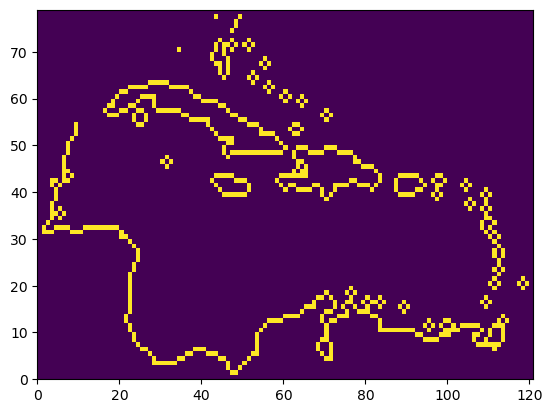

In [97]:

    plt.pcolormesh(clme_mask)

In [98]:
    D=nemo.dataset['bathymetry']
    D.values[D.values==0]=np.nan
    

In [99]:
    Dcoast=D.values*clme_mask
    print(Dcoast)
    

[[ 0.  0.  0. ... nan  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]]


In [100]:
    Dcoast[Dcoast==0]=np.nan
    

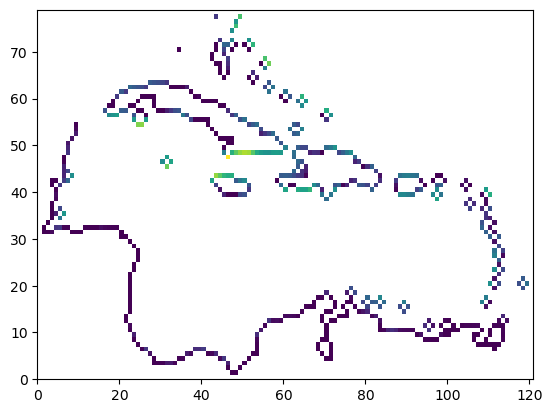

In [101]:
   plt.pcolormesh(Dcoast)

In [102]:
    np.nanmax(Dcoast)

np.float64(4530.94580078125)

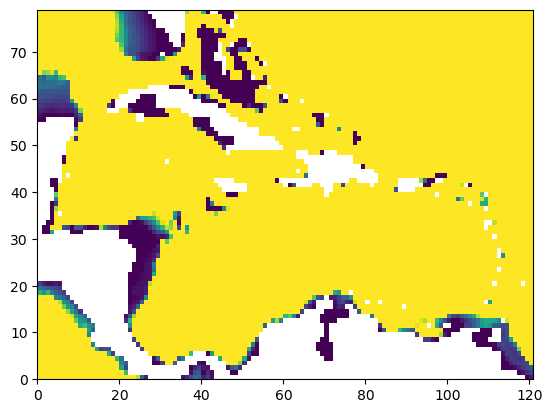

In [103]:
    plt.pcolormesh(D,vmax=200)    